# Fetal Head Circumference Estimation from Ultrasound Images  
## Notebook 01 – Exploratory Data Analysis (EDA)

This project uses deep learning techniques to estimate fetal head circumference (HC) from 2D ultrasound images.

We aim to develop a model that learns to predict the HC value from each ultrasound image, based on pixel-level information and real clinical measurements.

In this notebook, we perform an initial exploration of the dataset to:
- Understand the structure and content of the data
- Visualize sample ultrasound images
- Analyze the distribution of head circumference values
- Prepare for image preprocessing and model development in later steps

### Dataset Description

The training dataset (`training_set_pixel_size_and_HC.csv`) provides metadata for fetal ultrasound images, where each row corresponds to one image.

It contains the following columns:

- **filename**:  
  The name of the ultrasound image file (e.g., `001_HC.png`). Each image file contains a 2D grayscale scan of the fetal head. This filename will be used to load the corresponding image from disk.

- **pixel_spacing**:  
  The physical size of a single pixel in the image, measured in millimeters (mm).  
  For example, if `pixel_spacing = 0.06`, then one pixel represents 0.06 mm in the real world. This value is crucial when converting measurements in pixel units to actual head circumference in millimeters.

- **HC** *(Head Circumference)*:  
  The ground-truth head circumference of the fetus, measured in millimeters.  
  This value was likely measured manually by a medical professional and will be used as the target variable during training. The goal of the model is to predict this value from the image alone.



## 1-Data Exploration

In [9]:
import matplotlib.pyplot as plt
import cv2
import os
import random
import numpy as np

In [2]:
#import file
df = pd.read_csv('training_set_pixel_size_and_HC.csv')
#show the first row 
df.head()

,filename,pixel size(mm),head circumference (mm)
0,000_HC.png,0.069136,44.30
1,001_HC.png,0.089659,56.81
2,002_HC.png,0.062033,68.75
3,003_HC.png,0.091291,69.00
4,004_HC.png,0.061240,59.81


In [3]:
# show quick information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 999 non-null    object 
 1   pixel size(mm)           999 non-null    float64
 2   head circumference (mm)  999 non-null    float64
dtypes: float64(2), object(1)
memory usage: 23.5+ KB


In [4]:
# Quick summary stats
df.describe()

,pixel size(mm),head circumference (mm)
count,999.000000,999.000000
mean,0.139846,174.383093
std,0.053005,65.282061
min,0.049415,44.300000
25%,0.108801,153.600000
50%,0.128357,174.060000
75%,0.157678,189.825000
max,0.393280,346.400000


## 2. Visualize & Inspect Sample Ultrasound Images

In this step, we randomly select a few fetal ultrasound images and display them alongside their associated head circumference (HC) and pixel spacing. This helps us understand the quality of the images, assess image dimensions, verify grayscale consistency, and prepare for preprocessing and model input requirements.


In [46]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

# Your image folder — update if needed
image_folder = r'C:\Users\20111\OneDrive - Faculty Of Business (Ain Shams University)\Documents\machine learning og my theise\خمسات التربه\evaluate_set'

# Get list of image files
all_images = [f for f in os.listdir(image_folder) if f.endswith('.png')]

# Print total count
print(f"📸 Total number of image files in folder: {len(image_files)}")

📸 Total number of image files in folder: 335


In [48]:
# Show first 10 filenames
print("\n🗂️ Sample filenames:")
print(image_files[:10])

# Check extensions (maybe there's more than just .png?)
extensions = set([os.path.splitext(f)[1] for f in os.listdir(image_folder)])
print(f"\n📁 Unique file extensions in the folder: {extensions}")


🗂️ Sample filenames:


TypeError: 'set' object is not subscriptable

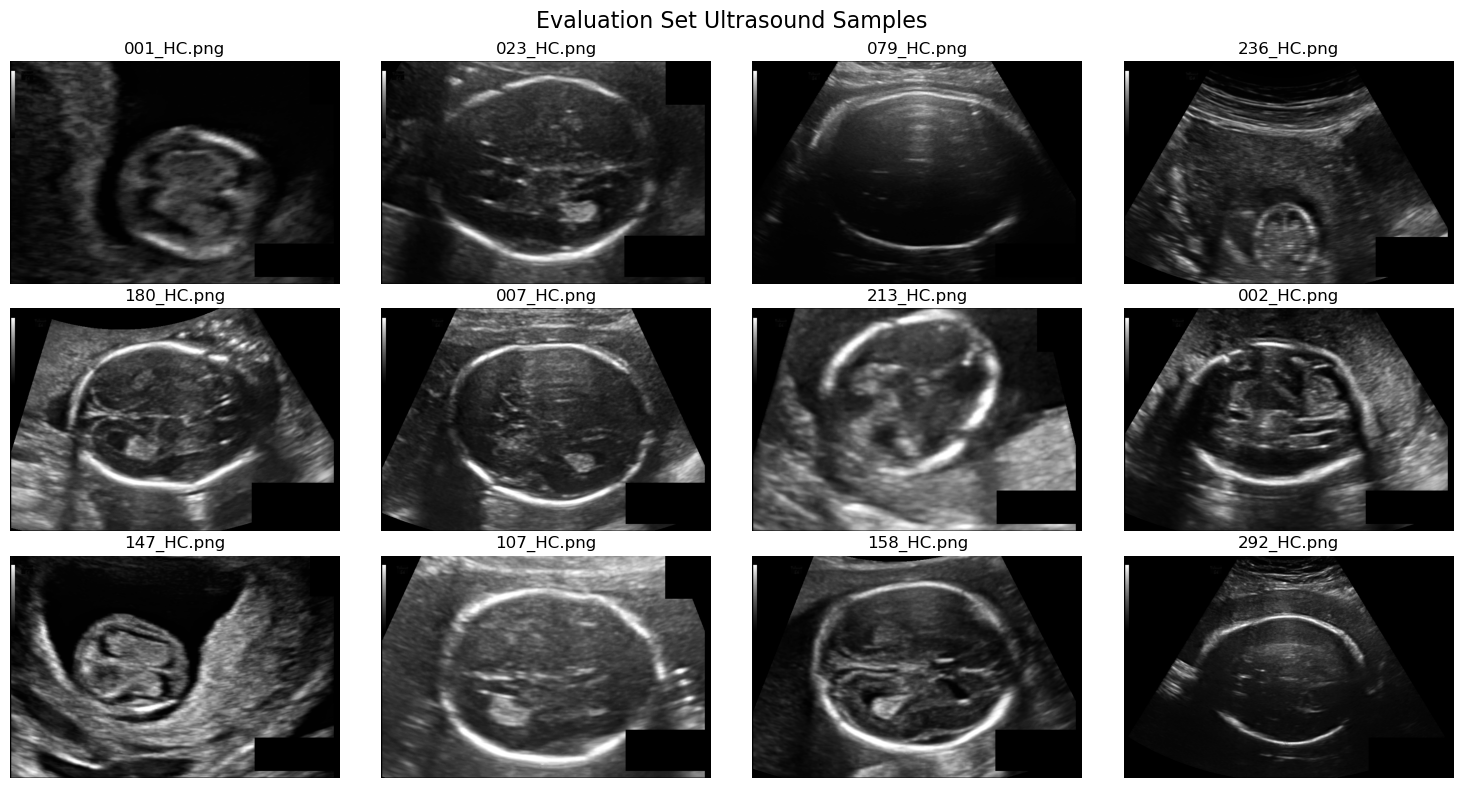

In [47]:
# Sample 6 images
sample_filenames = random.sample(all_images, 12)
# Display them
plt.figure(figsize=(15, 8))

for i, filename in enumerate(sample_filenames):
    image_path = os.path.join(image_folder, filename)

    plt.subplot(3, 4, i + 1)
    try:
        img = Image.open(image_path).convert('L')  # Ensure grayscale
        plt.imshow(img, cmap='gray')
        plt.title(filename)
    except Exception as e:
        plt.imshow([[1]], cmap='Reds')
        plt.title(f"FAILED: {filename}", color='red')
        print(f"❌ Error loading {filename}: {e}")

    plt.axis('off')

plt.suptitle("Evaluation Set Ultrasound Samples", fontsize=16)
plt.tight_layout()
plt.show()


## 3.0 Match Image Metadata with Actual Files

Before we perform preprocessing or modeling, we ensure that every filename listed in the metadata CSV has a corresponding image file in the folder.


In [45]:
# Make sure filenames are clean
df['filename'] = df['filename'].astype(str).str.strip()

# Get actual image filenames from the folder
image_folder = r'C:\Users\20111\OneDrive - Faculty Of Business (Ain Shams University)\Documents\machine learning og my theise\خمسات التربه\evaluate_set'
image_files = set(os.listdir(image_folder))

# Filter the CSV to only those that exist as files
df = df[df['filename'].isin(image_files)].reset_index(drop=True)

print(f"✅ Matched CSV and image folder. Remaining rows: {len(df)}")


✅ Matched CSV and image folder. Remaining rows: 335
